**Part 1. Linear Regression (Netflix: Release Year -> Movie Duration)**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/netflix_titles.csv")

In [3]:
np.random.seed(42)

df_raw = pd.read_csv("netflix_titles.csv")
df_lin = df_raw[df_raw["type"] == "Movie"].copy()
df_lin["duration_min"] = df_lin["duration"].str.extract(r"(\d+)").astype(float)
df_lin = df_lin.dropna(subset=["duration_min"])

In [4]:
x = df_lin["release_year"].values.astype(float)
y = df_lin["duration_min"].values.astype(float)

In [5]:
x_mean, x_std = x.mean(), x.std()
x_norm = (x - x_mean) / x_std

In [6]:
idx = np.random.permutation(len(x_norm))
split = int(0.8 * len(x_norm))
train_idx, test_idx = idx[:split], idx[split:]
x_train, y_train = x_norm[train_idx], y[train_idx]
x_test, y_test = x_norm[test_idx], y[test_idx]

In [7]:
w, b = 0.0, 0.0
learning_rate = 0.01
epochs = 1000

n = len(x_train)
losses = []
for epoch in range(epochs):
    y_pred = w * x_train + b            # predict
    error = y_pred - y_train
    loss = np.mean(error ** 2)          # MSE loss
    losses.append(loss)

    dw = (2 / n) * np.sum(error * x_train)   # dL/dw
    db = (2 / n) * np.sum(error)             # dL/db

    w -= learning_rate * dw             # gradient descent update
    b -= learning_rate * db

    if epoch % 200 == 0:
        print(f"epoch {epoch:4d} | loss {loss:.4f} | w {w:.4f} | b {b:.4f}")

print(f"Final -> w = {w:.4f}, b = {b:.4f}")

epoch    0 | loss 10662.8554 | w -0.1226 | b 1.9863
epoch  200 | loss 766.8329 | w -5.7695 | b 97.5988
epoch  400 | loss 763.7770 | w -5.8506 | b 99.2800
epoch  600 | loss 763.7761 | w -5.8517 | b 99.3096
epoch  800 | loss 763.7761 | w -5.8517 | b 99.3101
Final -> w = -5.8517, b = 99.3101


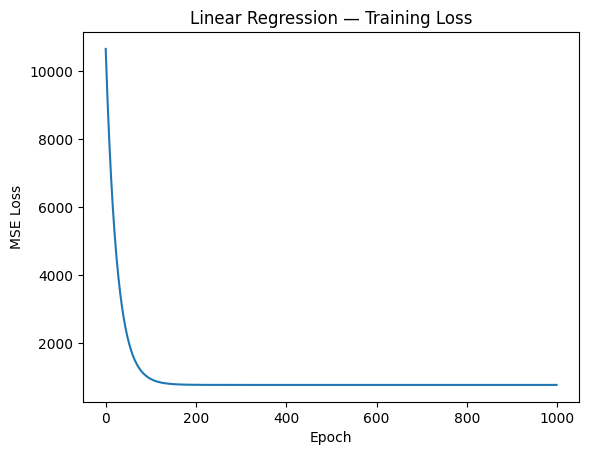

In [8]:
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.title("Linear Regression — Training Loss")
plt.show()

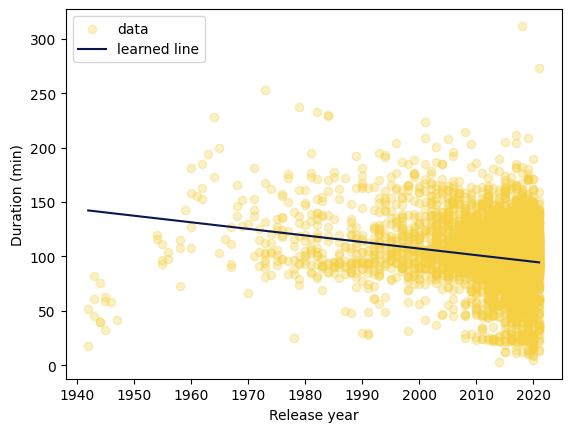

In [20]:
plt.scatter(x, y, alpha=0.3, label="data", c = "#F5D042")
x_line = np.linspace(x.min(), x.max(), 100)
x_line_norm = (x_line - x_mean) / x_std
plt.plot(x_line, w * x_line_norm + b, c = "#0A174E", label="learned line")
plt.xlabel("Release year"); plt.ylabel("Duration (min)"); plt.legend()
plt.show()

In [21]:
y_test_pred = w * x_test + b
mse_test = np.mean((y_test_pred - y_test) ** 2)
ss_res = np.sum((y_test - y_test_pred) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"Test MSE: {mse_test:.4f}, Test R^2: {r2:.4f}")

Test MSE: 776.1232, Test R^2: 0.0347


**Part 2. Logistic Regression (Netflix: Movie vs TV show)**

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [23]:
df_raw = pd.read_csv("netflix_titles.csv")

In [24]:
df = df_raw.copy()
df["type_binary"] = (df["type"] == "TV Show").astype(int)
df["country"] = df["country"].fillna("Unknown")
df["country_us"] = df["country"].str.contains("United States").astype(int)
df["genre_count"] = df["listed_in"].apply(lambda g: len(str(g).split(",")))

X = df[["release_year", "country_us", "genre_count"]].values.astype(float)   # FEATURES
y = df["type_binary"].values.astype(float)                                   # TARGET

X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_norm = (X - X_mean) / X_std

In [25]:
idx = np.random.permutation(len(X_norm))
split = int(0.8 * len(X_norm))
train_idx, test_idx = idx[:split], idx[split:]
X_train, y_train = X_norm[train_idx], y[train_idx]
X_test, y_test = X_norm[test_idx], y[test_idx]

In [26]:
w = np.zeros(3)   # w1->release_year, w2->country_us, w3->genre_count
b = 0.0
learning_rate = 0.01
epochs = 1000

n = len(X_train)
losses = []
eps = 1e-9
for epoch in range(epochs):
    z = X_train @ w + b
    p = sigmoid(z)

    loss = -np.mean(y_train * np.log(p + eps) + (1 - y_train) * np.log(1 - p + eps))
    losses.append(loss)

    error = p - y_train                        # dL/dz (chain rule collapses here)
    dw = (1 / n) * (X_train.T @ error)          # dL/dw
    db = (1 / n) * np.sum(error)                # dL/db

    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 200 == 0:
        print(f"epoch {epoch:4d} | loss {loss:.4f}")


epoch    0 | loss 0.6931
epoch  200 | loss 0.6301
epoch  400 | loss 0.6058
epoch  600 | loss 0.5953
epoch  800 | loss 0.5902


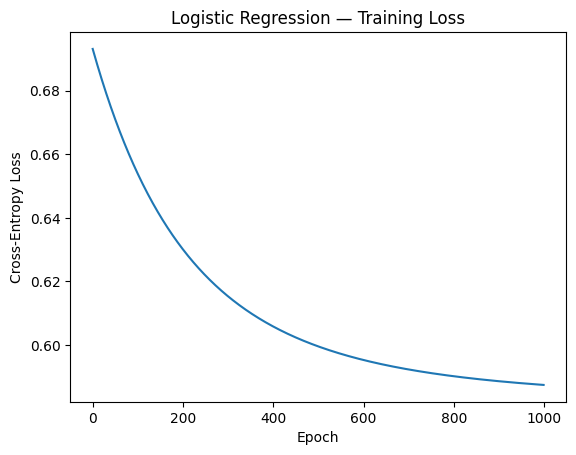

In [27]:
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("Cross-Entropy Loss"); plt.title("Logistic Regression — Training Loss")
plt.show()

In [28]:
p_test = sigmoid(X_test @ w + b)
pred = (p_test >= 0.5).astype(int)
accuracy = np.mean(pred == y_test)
print(f"Test accuracy @ threshold 0.5: {accuracy:.4f}")

Test accuracy @ threshold 0.5: 0.6913


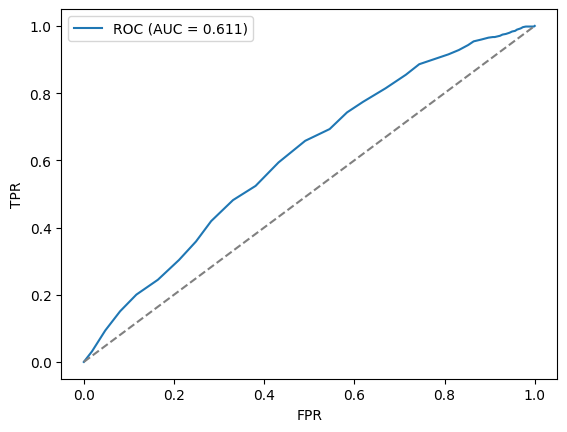

AUC: 0.6110


In [29]:
thresholds = np.linspace(0, 1, 101)
tprs, fprs = [], []
P = np.sum(y_test == 1)
N = np.sum(y_test == 0)
for t in thresholds:
    pred_t = (p_test >= t).astype(int)
    tp = np.sum((pred_t == 1) & (y_test == 1))
    fp = np.sum((pred_t == 1) & (y_test == 0))
    tprs.append(tp / P)
    fprs.append(fp / N)
tprs, fprs = np.array(tprs), np.array(fprs)

order = np.argsort(fprs)
auc = np.trapezoid(tprs[order], fprs[order])

plt.plot(fprs[order], tprs[order], label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
plt.show()
print(f"AUC: {auc:.4f}")

In [30]:
best_idx = np.argmax(tprs - fprs)
best_threshold = thresholds[best_idx]
best_accuracy = np.mean((p_test >= best_threshold).astype(int) == y_test)
print(f"Best threshold: {best_threshold:.2f}, accuracy: {best_accuracy:.4f}")

Best threshold: 0.33, accuracy: 0.5551
